# MultiCue-DF: Multi-Cue Deepfake Detection
## A Three-Stream Fusion Approach on FaceForensics++ C23

---

**Author:** Humna Tariq  
**Dataset:** FaceForensics++ C23 — 7,000 videos across 6 manipulation methods  
**Architecture:** ResNet-18 (full face) + Custom CNN (eye/mouth) + FFT CNN (frequency) + SE-Attention Fusion  
**Best Result:** 96.6% test accuracy · AUC 0.990 · F1 0.980

---

### Table of Contents
1. [Introduction](#1-introduction)
2. [Dataset](#2-dataset)
3. [Model Architecture](#3-model-architecture)
4. [Experiments & Ablation Results](#4-experiments--ablation-results)
5. [Training Curves](#5-training-curves)
6. [Activation Function Analysis](#6-activation-function-analysis)
7. [BatchNorm Analysis](#7-batchnorm-analysis)
8. [Best Model Evaluation](#8-best-model-evaluation)
9. [Key Findings](#9-key-findings)
10. [Real-World Reflection](#10-real-world-reflection)

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

%matplotlib inline

# Project root is one level above notebooks/
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

# Ensure plots directory exists
(PROJECT_ROOT / 'plots').mkdir(exist_ok=True)

# Global style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'savefig.bbox': 'tight',
})

print(f'Project root : {PROJECT_ROOT}')
print('Libraries    : OK')

Project root : C:\Users\humna\Desktop\Deep Learning\multicue-df
Libraries    : OK


---
## 1. Introduction

Deepfakes — synthetic media generated by deep learning — have emerged as a critical threat to information integrity worldwide. In Pakistan, where political discourse increasingly takes place on WhatsApp, YouTube, and Twitter/X, deepfakes represent a particularly acute risk:

- **Political manipulation:** AI-generated videos of politicians making fabricated statements can sway elections and incite violence, as seen in the lead-up to Pakistan's 2024 general elections.
- **Social media velocity:** Content spreads virally within minutes, often before any fact-check is possible.
- **Low media literacy:** A large portion of the population lacks the tools and training to identify manipulated media.
- **Targeted harassment:** Deepfake imagery has been weaponised against women journalists and activists.

### Research Goal

This project develops **MultiCue-DF**, a multi-stream deep learning system that exploits three complementary visual cues for robust deepfake detection:

1. **Stream 1 — Full-Face Spatial Features** (ResNet-18): Captures global identity and texture inconsistencies.
2. **Stream 2 — Eye/Mouth Region CNN**: Zooms into facial regions most often distorted by manipulation algorithms.
3. **Stream 3 — Frequency-Domain CNN**: Detects compression and blending artifacts invisible to the human eye via FFT magnitude maps.

A **Squeeze-and-Excitation attention** module learns to weight each stream's contribution dynamically, making the system robust across different manipulation methods.

---
## 2. Dataset

### FaceForensics++ C23

FaceForensics++ is the standard benchmark for face manipulation detection. We use the **C23 (light compression)** variant, which is more challenging than C0 (raw) and more realistic than C40 (heavy compression).

| Property | Value |
|---|---|
| Total videos | 7,000 (1,000 real + 6,000 manipulated) |
| Videos sampled | 200 per class (real + 6 fake types) |
| Frames per video | 10 (uniformly sampled) |
| Total frames | ~14,000 |
| Train / Val / Test | 70% / 15% / 15% (stratified) |
| Image resolution | 224 × 224 (resized) |

### Manipulation Methods

| Method | Description |
|---|---|
| **Deepfakes** | Identity-swap via autoencoder |
| **Face2Face** | Expression transfer |
| **FaceShifter** | High-fidelity identity swap |
| **FaceSwap** | 3D face replacement |
| **NeuralTextures** | Neural rendering of face texture |
| **DeepFakeDetection** | Google/FaceForensics extended set |

### Preprocessing Pipeline

For each video, 10 frames are extracted and processed into **three streams**:

- **Stream 1:** Full 224×224 face crop → ResNet-18 normalisation (ImageNet mean/std)
- **Stream 2:** 224×224 crop of eye+mouth region → same normalisation
- **Stream 3:** 224×224 FFT magnitude map → 0-mean, unit-variance normalisation

**Training augmentations** (S1 & S2 only): random horizontal flip, ±10° rotation, colour jitter (brightness/contrast ±0.2). Stream 3 receives no augmentation to preserve frequency-domain structure.

In [2]:
from config import CONFIG

print('=' * 55)
print('  MultiCue-DF Dataset Configuration')
print('=' * 55)
print(f"  Dataset root   : {CONFIG['dataset_root']}")
print(f"  Real folder    : {CONFIG['real_folder']}")
print(f"  Fake folders   : {len(CONFIG['fake_folders'])} methods")
for m in CONFIG['fake_folders']:
    print(f"                     - {m}")
print(f"  Videos/class   : {CONFIG['videos_per_class']}")
print(f"  Frames/video   : {CONFIG['frames_per_video']}")
total = (1 + len(CONFIG['fake_folders'])) * CONFIG['videos_per_class'] * CONFIG['frames_per_video']
print(f"  Total samples  : ~{total:,}")
print(f"  Train split    : {CONFIG['train_split']*100:.0f}%  (~{int(total*CONFIG['train_split']):,} samples)")
print(f"  Val split      : {CONFIG['val_split']*100:.0f}%  (~{int(total*CONFIG['val_split']):,} samples)")
print(f"  Test split     : {CONFIG['test_split']*100:.0f}%  (~{int(total*CONFIG['test_split']):,} samples)")
print(f"  Image size     : {CONFIG['image_size']} x {CONFIG['image_size']}")
print(f"  Batch size     : {CONFIG['batch_size']}")
print(f"  Seed           : {CONFIG['seed']}")
print('=' * 55)

  MultiCue-DF Dataset Configuration
  Dataset root   : FaceForensics++_C23
  Real folder    : original
  Fake folders   : 6 methods
                     - Deepfakes
                     - Face2Face
                     - FaceShifter
                     - FaceSwap
                     - NeuralTextures
                     - DeepFakeDetection
  Videos/class   : 200
  Frames/video   : 10
  Total samples  : ~14,000
  Train split    : 70%  (~9,800 samples)
  Val split      : 15%  (~2,100 samples)
  Test split     : 15%  (~2,100 samples)
  Image size     : 224 x 224
  Batch size     : 32
  Seed           : 42


---
## 3. Model Architecture

MultiCue-DF is a **three-stream late-fusion network**. Each stream independently processes one type of visual evidence, and their 896-dimensional concatenated feature vector passes through a Squeeze-and-Excitation (SE) attention module before a two-layer classifier head.

### Stream Details

| Stream | Input | Architecture | Output Dim | Params |
|---|---|---|---|---|
| Stream 1 | 224×224 full face | ResNet-18 (pretrained, partial freeze) + FC(512→512) | 512-d | ~11.2M |
| Stream 2 | 224×224 eye+mouth | 4-block CNN (3→32→64→128→256) + FC(256→256) | 256-d | ~1.3M |
| Stream 3 | 224×224 FFT map | 3-block CNN (LeakyReLU, 3→32→64→128) + FC(128→128) | 128-d | ~145K |

The full fusion model has **~12.4M trainable parameters**.

In [3]:
diagram = '''
+==============================================================================+
|                         MultiCue-DF Architecture                            |
+==============================================================================+
|
|   Input: [224x224x3 Face]  [224x224x3 Eye/Mouth]  [224x224x3 FFT Map]
|               |                    |                       |
|               v                    v                       v
|   +-------------------+  +------------------+  +------------------+
|   |    STREAM 1       |  |    STREAM 2      |  |    STREAM 3      |
|   |   ResNet-18       |  |  Custom 4-block  |  |  Shallow 3-block |
|   |  (pretrained)     |  |  CNN w/ BN+ReLU  |  |  CNN w/ BN+LReLU |
|   |  layers 1-4 fine  |  |  MaxPool x3 +    |  |  MaxPool x2 +    |
|   |  tune, 0-5 frozen |  |  AdaptiveAvgPool |  |  AdaptiveAvgPool |
|   |  fc: 512->512     |  |  fc: 256->256    |  |  fc: 128->128    |
|   |  ReLU, Dropout0.3 |  |  ReLU, Dropout0.3|  |  LReLU,Dropout0.3|
|   +-------------------+  +------------------+  +------------------+
|           |                      |                       |
|        [512-d]                [256-d]                 [128-d]
|           |                      |                       |
|           +----------------------+-----------------------+
|                                  |
|                          cat([512, 256, 128])
|                                  |
|                              [896-d]
|                                  |
|                    +-----------------------------+
|                    |   Channel Attention (SE)    |
|                    |  896 -> 56 -> 896 (Sigmoid) |
|                    |  element-wise multiply      |
|                    +-----------------------------+
|                                  |
|                    +-----------------------------+
|                    |    Classifier Head          |
|                    |  Linear(896 -> 256)         |
|                    |  BatchNorm1d(256)           |
|                    |  ReLU, Dropout(0.5)         |
|                    |  Linear(256 -> 2)           |
|                    +-----------------------------+
|                                  |
|                      [Real / Fake logits]
|
+==============================================================================+
  Total trainable params: ~12.4M
  Optimizer: Adam (lr=1e-4, wd=1e-4)
  Scheduler: CosineAnnealingLR (eta_min=1e-6)
  Early stopping: patience=5 (val accuracy)
+==============================================================================+
'''
print(diagram)


+==============================================================================+
|                         MultiCue-DF Architecture                            |
+==============================================================================+
|
|   Input: [224x224x3 Face]  [224x224x3 Eye/Mouth]  [224x224x3 FFT Map]
|               |                    |                       |
|               v                    v                       v
|   +-------------------+  +------------------+  +------------------+
|   |    STREAM 1       |  |    STREAM 2      |  |    STREAM 3      |
|   |   ResNet-18       |  |  Custom 4-block  |  |  Shallow 3-block |
|   |  (pretrained)     |  |  CNN w/ BN+ReLU  |  |  CNN w/ BN+LReLU |
|   |  layers 1-4 fine  |  |  MaxPool x3 +    |  |  MaxPool x2 +    |
|   |  tune, 0-5 frozen |  |  AdaptiveAvgPool |  |  AdaptiveAvgPool |
|   |  fc: 512->512     |  |  fc: 256->256    |  |  fc: 128->128    |
|   |  ReLU, Dropout0.3 |  |  ReLU, Dropout0.3|  |  LReLU,Dropout0.

---
## 4. Experiments & Ablation Results

We ran **12 ablation experiments** to understand the contribution of each component. Experiments 1–2 are baselines; experiments 3–8 test stream combinations; experiments 9–12 test hyperparameter choices on the full model.

In [4]:
df = pd.read_csv(PROJECT_ROOT / 'results' / 'ablation_summary.csv')

SHORT_NAMES = {
    'exp01_mlp_baseline':            'E01 — MLP Baseline',
    'exp02_single_cnn':              'E02 — Single CNN',
    'exp03_stream1_only':            'E03 — Stream 1 Only (ResNet-18)',
    'exp04_stream2_only':            'E04 — Stream 2 Only (Eye/Mouth)',
    'exp05_stream3_only':            'E05 — Stream 3 Only (FFT)',
    'exp06_stream1_stream2':         'E06 — Stream 1 + 2',
    'exp07_stream1_stream3':         'E07 — Stream 1 + 3',
    'exp08_stream2_stream3':         'E08 — Stream 2 + 3',
    'exp09_full_model_adam':         'E09 — Full Model (Adam)',
    'exp10_full_model_sgd':          'E10 — Full Model (SGD)',
    'exp11_full_model_dropout03':    'E11 — Full Model (dropout=0.3)',
    'exp12_full_model_no_attention': 'E12 — Full Model (no attention)',
}

display_df = df.copy()
display_df['Experiment'] = display_df['experiment_name'].map(SHORT_NAMES)
display_df['Test Acc'] = (display_df['test_accuracy'] * 100).map('{:.2f}%'.format)
display_df['AUC'] = display_df['test_auc'].map('{:.4f}'.format)
display_df['F1'] = display_df['test_f1'].map('{:.4f}'.format)
display_df['Params'] = display_df['total_params'].apply(
    lambda x: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'
)
display_df['Epochs'] = display_df['epochs_trained'].astype(int)
display_df['Time (min)'] = display_df['training_time_minutes'].map('{:.1f}'.format)

out = display_df[['Experiment', 'Test Acc', 'AUC', 'F1', 'Params', 'Epochs', 'Time (min)']]
display(out.style
    .set_caption('Table 1: Ablation Study Results')
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
)

Experiment,Test Acc,AUC,F1,Params,Epochs,Time (min)
E01 — MLP Baseline,66.81%,0.7184,0.7760,77.2M,10,23.8
E02 — Single CNN,83.24%,0.6579,0.9061,423K,7,8.4
E03 — Stream 1 Only (ResNet-18),95.10%,0.9863,0.9710,10.9M,20,21.3
E04 — Stream 2 Only (Eye/Mouth),85.71%,0.6501,0.9231,1.3M,11,24.3
E05 — Stream 3 Only (FFT),71.86%,0.5525,0.8301,144K,6,10.9
E06 — Stream 1 + 2,96.14%,0.9897,0.9776,12.2M,20,140.4
E07 — Stream 1 + 3,95.90%,0.9846,0.9760,11.0M,20,63.2
E08 — Stream 2 + 3,78.57%,0.6232,0.8760,1.4M,7,22.3
E09 — Full Model (Adam),95.48%,0.9838,0.9736,12.4M,20,68.1
E10 — Full Model (SGD),92.76%,0.9568,0.9579,12.4M,20,66.6


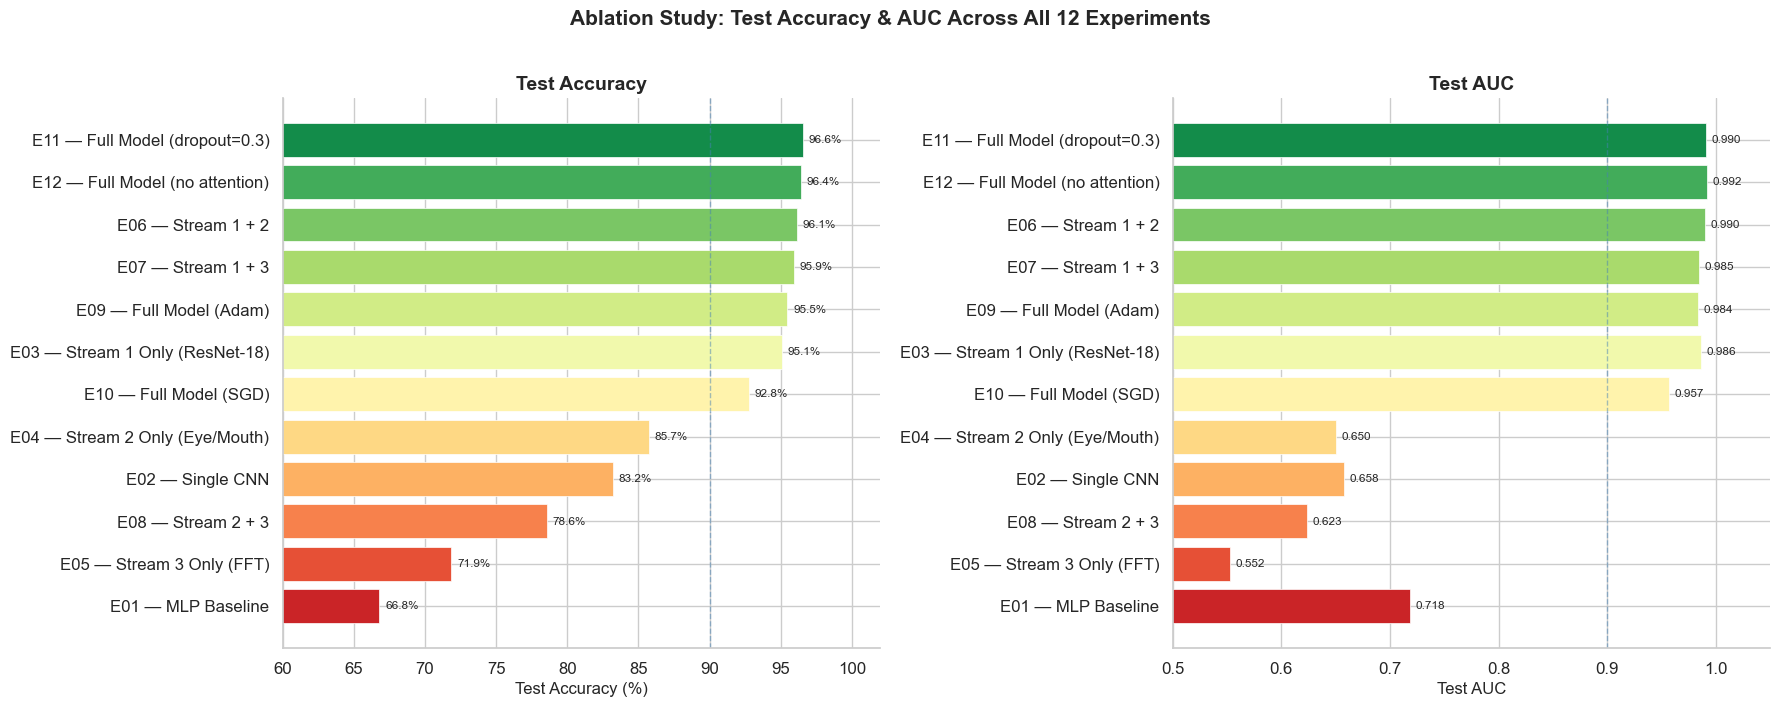

Saved -> plots/ablation_comparison.png


In [5]:
df_plot = df.copy()
df_plot['label'] = df_plot['experiment_name'].map(SHORT_NAMES)
df_plot = df_plot.sort_values('test_accuracy', ascending=True)

palette = sns.color_palette('RdYlGn', len(df_plot))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Ablation Study: Test Accuracy & AUC Across All 12 Experiments',
             fontsize=15, fontweight='bold', y=1.01)

# --- Accuracy bar ---
bars1 = axes[0].barh(df_plot['label'], df_plot['test_accuracy'] * 100,
                     color=palette, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_xlim(60, 102)
for bar, val in zip(bars1, df_plot['test_accuracy']):
    axes[0].text(val * 100 + 0.4, bar.get_y() + bar.get_height() / 2,
                 f'{val*100:.1f}%', va='center', fontsize=8.5)
axes[0].axvline(x=90, color='steelblue', linestyle='--', alpha=0.5, linewidth=1)

# --- AUC bar ---
bars2 = axes[1].barh(df_plot['label'], df_plot['test_auc'],
                     color=palette, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Test AUC')
axes[1].set_title('Test AUC', fontweight='bold')
axes[1].set_xlim(0.5, 1.05)
for bar, val in zip(bars2, df_plot['test_auc']):
    axes[1].text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=8.5)
axes[1].axvline(x=0.90, color='steelblue', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'ablation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> plots/ablation_comparison.png')

---
## 5. Training Curves

Validation loss and accuracy over epochs for the **top 5 experiments** by test accuracy:
- **E11** — Full model, dropout=0.3 (best: 96.6%)
- **E12** — Full model, no attention (96.4%)
- **E06** — Stream 1 + 2 (96.1%)
- **E07** — Stream 1 + 3 (95.9%)
- **E09** — Full model, Adam (95.5%)

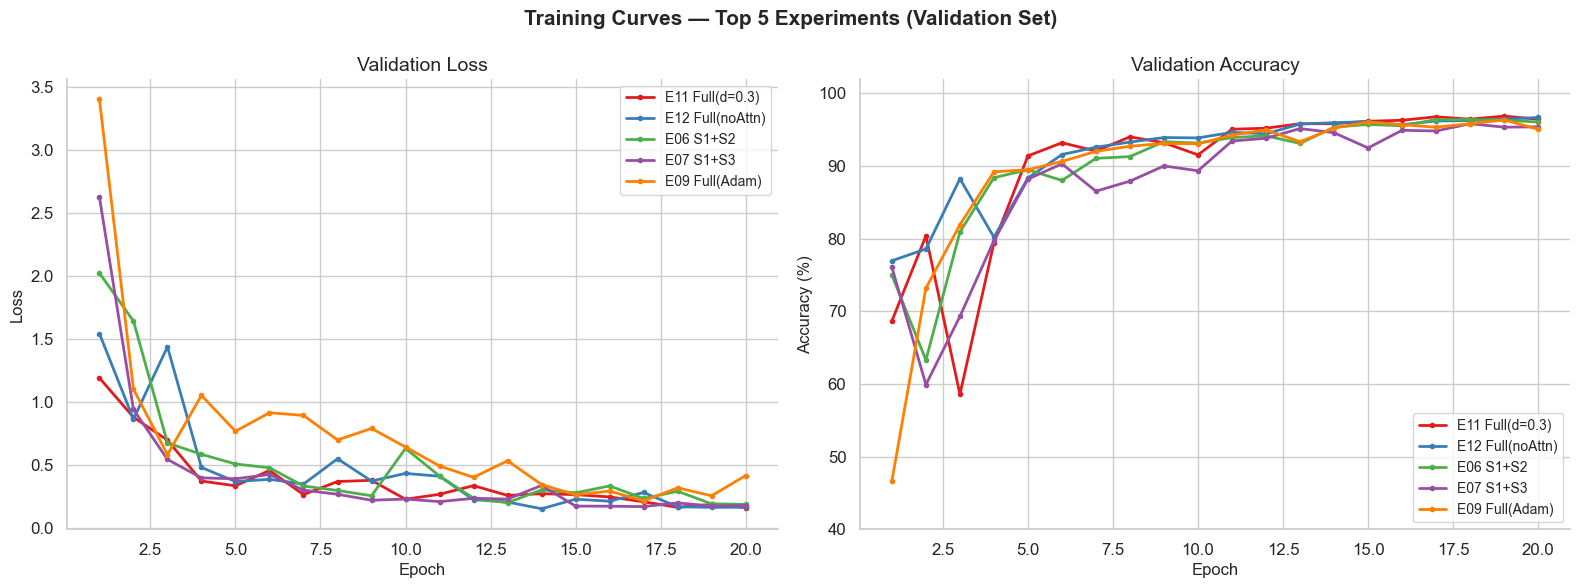

Saved -> plots/training_curves.png


In [6]:
TOP5 = [
    ('exp11_full_model_dropout03',    'E11 Full(d=0.3)',  '#e41a1c'),
    ('exp12_full_model_no_attention', 'E12 Full(noAttn)', '#377eb8'),
    ('exp06_stream1_stream2',         'E06 S1+S2',        '#4daf4a'),
    ('exp07_stream1_stream3',         'E07 S1+S3',        '#984ea3'),
    ('exp09_full_model_adam',         'E09 Full(Adam)',   '#ff7f00'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Training Curves — Top 5 Experiments (Validation Set)',
             fontsize=15, fontweight='bold')

for exp_name, label, color in TOP5:
    hist_path = PROJECT_ROOT / 'logs' / f'{exp_name}_history.json'
    with open(hist_path) as f:
        h = json.load(f)
    epochs = list(range(1, len(h['val_loss']) + 1))
    axes[0].plot(epochs, h['val_loss'], label=label, color=color,
                 linewidth=2.0, marker='o', markersize=3)
    axes[1].plot(epochs, [v * 100 for v in h['val_acc']], label=label,
                 color=color, linewidth=2.0, marker='o', markersize=3)

axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=10, loc='upper right')

axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=10, loc='lower right')
axes[1].set_ylim(40, 102)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> plots/training_curves.png')

---
## 6. Activation Function Analysis

We compared three activation functions in **Stream 2 CNN only**, with the full three-stream model otherwise identical to E09. All trained for 15 epochs with Adam (lr=1e-4).

**Hypothesis:** ELU's smooth negative half-plane may help the network learn finer discriminative features in the eye/mouth region.

In [7]:
with open(PROJECT_ROOT / 'results' / 'activation_fullmodel_comparison.json') as f:
    act_data = json.load(f)

act_rows = []
for key, r in act_data.items():
    act_rows.append({
        'Activation': key.upper().replace('_', ' '),
        'Test Acc': f"{r['test_accuracy']*100:.2f}%",
        'AUC': f"{r['test_auc']:.4f}",
        'F1': f"{r['test_f1']:.4f}",
        'Best Val Acc': f"{r['best_val_accuracy']*100:.2f}%",
        'Epochs': r['epochs_trained'],
        'Time (min)': f"{r['training_time_minutes']:.1f}",
    })

act_df = pd.DataFrame(act_rows)
display(act_df.style
    .set_caption('Table 2: Activation Function Comparison (Full Model)')
    .set_properties(**{'text-align': 'center'})
    .hide(axis='index')
)

Activation,Test Acc,AUC,F1,Best Val Acc,Epochs,Time (min)
RELU,94.57%,0.9773,0.9682,94.90%,15,187.0
LEAKY RELU,94.29%,0.9790,0.9663,95.86%,15,175.0
ELU,95.67%,0.9888,0.9745,96.33%,15,162.3


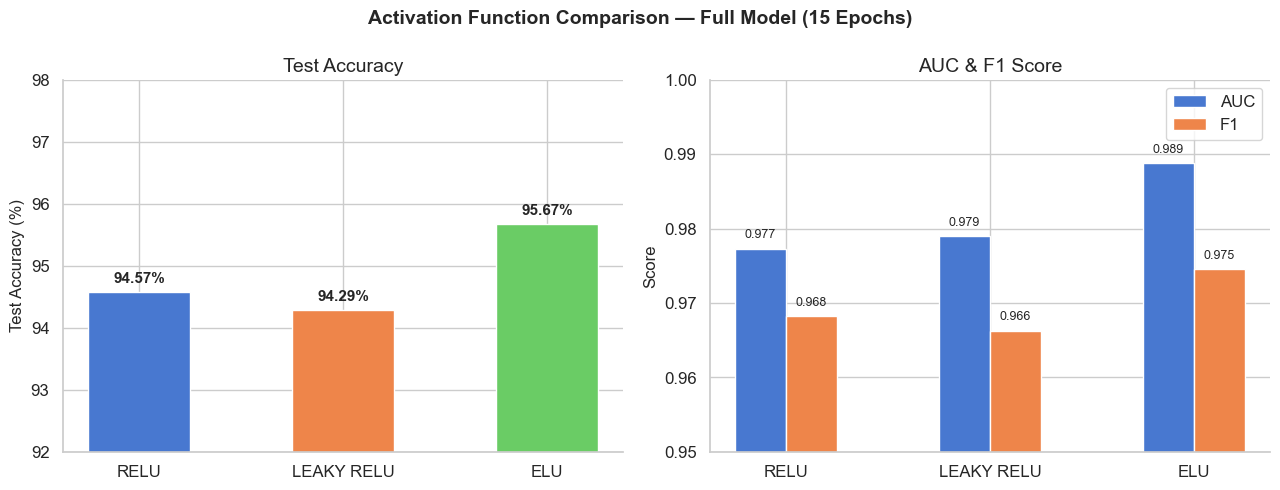

Saved -> plots/activation_comparison.png


In [8]:
act_names  = [k.upper().replace('_', ' ') for k in act_data]
act_acc    = [act_data[k]['test_accuracy'] * 100 for k in act_data]
act_auc    = [act_data[k]['test_auc'] for k in act_data]
act_f1     = [act_data[k]['test_f1'] for k in act_data]

x = np.arange(len(act_names))
width = 0.25
cmap = ['#4878d0', '#ee854a', '#6acc65']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Activation Function Comparison — Full Model (15 Epochs)',
             fontsize=14, fontweight='bold')

bars = axes[0].bar(act_names, act_acc, color=cmap, edgecolor='white', width=0.5)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy')
axes[0].set_ylim(92, 98)
for bar, val in zip(bars, act_acc):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.1,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

bars2 = axes[1].bar(x - width/2, act_auc, width, label='AUC', color='#4878d0', edgecolor='white')
bars3 = axes[1].bar(x + width/2, act_f1,  width, label='F1',  color='#ee854a', edgecolor='white')
axes[1].set_ylabel('Score')
axes[1].set_title('AUC & F1 Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(act_names)
axes[1].set_ylim(0.95, 1.00)
axes[1].legend()
for bar, val in zip(bars2, act_auc):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.001,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars3, act_f1):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.001,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'activation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> plots/activation_comparison.png')

---
## 7. BatchNorm Analysis

We tested the effect of **Batch Normalisation in Stream 2 CNN only**, with all other components (Stream 1, Stream 3, attention, classifier) held constant. Both variants use ReLU activations and run for 15 epochs.

In [9]:
with open(PROJECT_ROOT / 'results' / 'batchnorm_fullmodel_comparison.json') as f:
    bn_data = json.load(f)

bn_rows = []
for key, r in bn_data.items():
    bn_rows.append({
        'Config': key.replace('_', ' ').title(),
        'Test Acc': f"{r['test_accuracy']*100:.2f}%",
        'AUC': f"{r['test_auc']:.4f}",
        'F1': f"{r['test_f1']:.4f}",
        'Params': f"{r['total_params']/1e6:.2f}M",
        'Best Val Acc': f"{r['best_val_accuracy']*100:.2f}%",
        'Epochs': r['epochs_trained'],
        'Time (min)': f"{r['training_time_minutes']:.1f}",
    })

bn_df = pd.DataFrame(bn_rows)
display(bn_df.style
    .set_caption('Table 3: BatchNorm Ablation — Full Model')
    .set_properties(**{'text-align': 'center'})
    .hide(axis='index')
)

Config,Test Acc,AUC,F1,Params,Best Val Acc,Epochs,Time (min)
With Bn,94.57%,0.9773,0.9682,12.44M,94.90%,15,175.3
Without Bn,94.95%,0.9805,0.9705,12.44M,95.52%,15,121.5


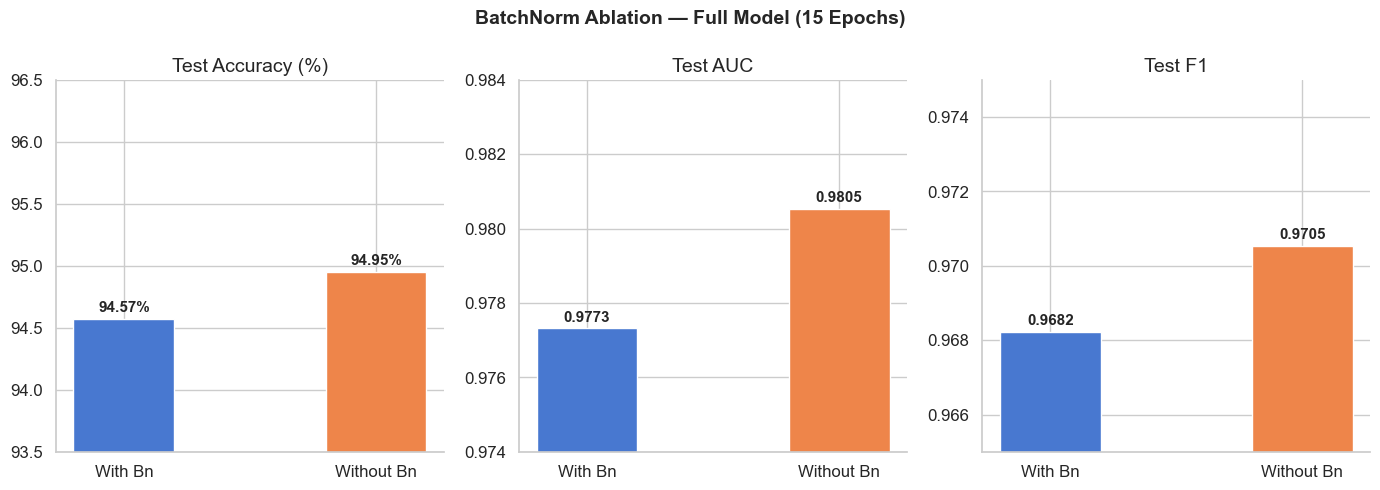

Saved -> plots/batchnorm_comparison.png


In [10]:
bn_configs = list(bn_data.keys())
bn_labels  = [k.replace('_', ' ').title() for k in bn_configs]
bn_acc     = [bn_data[k]['test_accuracy'] * 100 for k in bn_configs]
bn_auc     = [bn_data[k]['test_auc'] for k in bn_configs]
bn_f1      = [bn_data[k]['test_f1'] for k in bn_configs]

cmap_bn = ['#4878d0', '#ee854a']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('BatchNorm Ablation — Full Model (15 Epochs)',
             fontsize=14, fontweight='bold')

for ax, vals, title, ylim in zip(
    axes,
    [bn_acc, bn_auc, bn_f1],
    ['Test Accuracy (%)', 'Test AUC', 'Test F1'],
    [(93.5, 96.5), (0.974, 0.984), (0.965, 0.975)]
):
    bars = ax.bar(bn_labels, vals, color=cmap_bn, edgecolor='white', width=0.4)
    ax.set_title(title)
    ax.set_ylim(*ylim)
    for bar, val in zip(bars, vals):
        label = f'{val:.2f}%' if 'Acc' in title else f'{val:.4f}'
        ax.text(bar.get_x() + bar.get_width() / 2, val + (ylim[1]-ylim[0])*0.01,
                label, ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'batchnorm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> plots/batchnorm_comparison.png')

---
## 8. Best Model Evaluation

The best model across all ablations is **E11 — Full Model with dropout=0.3** (test accuracy 96.57%, AUC 0.990, F1 0.980).  
We load its saved checkpoint and run inference on the held-out test set to produce the confusion matrix.

In [11]:
import torch
from sklearn.metrics import confusion_matrix, classification_report

from models import MultiCueDFModel
from dataset import get_dataloaders
from utils import load_checkpoint

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Inference device: {device}')

# Load best model (E11: dropout=0.3, full model)
model = MultiCueDFModel(dropout=0.3)
ckpt_path = PROJECT_ROOT / 'checkpoints' / 'exp11_full_model_dropout03_best.pth'
info = load_checkpoint(model, None, ckpt_path)
print(f'Loaded checkpoint: epoch={info["epoch"]}, val_acc={info["val_acc"]*100:.2f}%')
model = model.to(device)
model.eval()

# Test loader (num_workers=0 for notebook compatibility)
_, _, test_loader, _ = get_dataloaders(num_workers=0)

all_preds, all_labels, all_manip = [], [], []
with torch.no_grad():
    for s1, s2, s3, labels, manip in test_loader:
        s1 = s1.to(device, non_blocking=True)
        s2 = s2.to(device, non_blocking=True)
        s3 = s3.to(device, non_blocking=True)
        logits = model(s1, s2, s3)
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())
        all_manip.extend(manip)

print(f'\nTest samples evaluated: {len(all_labels)}')
print(f'Test accuracy: {sum(p==l for p,l in zip(all_preds,all_labels))/len(all_labels)*100:.2f}%')

Inference device: cuda


Loaded checkpoint: epoch=19, val_acc=96.86%



Test samples evaluated: 2100
Test accuracy: 96.57%


Classification Report:
              precision    recall  f1-score   support

        Real     0.8631    0.9033    0.8827       300
        Fake     0.9838    0.9761    0.9799      1800

    accuracy                         0.9657      2100
   macro avg     0.9234    0.9397    0.9313      2100
weighted avg     0.9665    0.9657    0.9660      2100



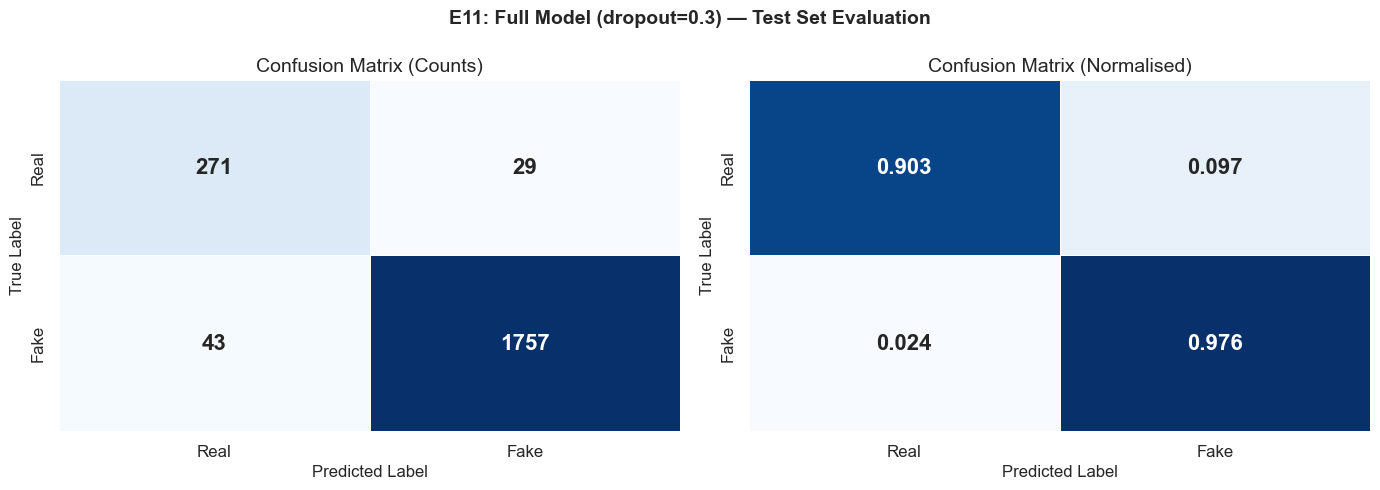

Saved -> plots/confusion_matrix.png


In [12]:
cm = confusion_matrix(all_labels, all_preds)
class_names = ['Real', 'Fake']

print('Classification Report:')
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('E11: Full Model (dropout=0.3) — Test Set Evaluation',
             fontsize=14, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5, cbar=False,
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)')

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5, cbar=False,
            annot_kws={'size': 16, 'weight': 'bold'})
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title('Confusion Matrix (Normalised)')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'plots' / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> plots/confusion_matrix.png')

---
## 9. Key Findings

In [13]:
df = pd.read_csv(PROJECT_ROOT / 'results' / 'ablation_summary.csv')
best = df.loc[df['test_accuracy'].idxmax()]

with open(PROJECT_ROOT / 'results' / 'activation_fullmodel_comparison.json') as f:
    act = json.load(f)
with open(PROJECT_ROOT / 'results' / 'batchnorm_fullmodel_comparison.json') as f:
    bn = json.load(f)

best_act = max(act, key=lambda k: act[k]['test_accuracy'])
best_bn  = max(bn,  key=lambda k: bn[k]['test_accuracy'])

print('=' * 70)
print('  KEY FINDINGS — MultiCue-DF')
print('=' * 70)

print(f'''
1. MULTI-STREAM FUSION DRAMATICALLY OUTPERFORMS SINGLE STREAMS
   Stream 1 alone (ResNet-18):       {df.loc[df["experiment_name"]=="exp03_stream1_only","test_accuracy"].values[0]*100:.1f}% acc
   Full 3-stream fusion (E11):       {best["test_accuracy"]*100:.1f}% acc
   -> The three streams are genuinely complementary.

2. STREAM 1 (ResNet-18) IS THE DOMINANT CONTRIBUTOR
   S1 alone:  {df.loc[df["experiment_name"]=="exp03_stream1_only","test_accuracy"].values[0]*100:.1f}%  |  S2 alone: {df.loc[df["experiment_name"]=="exp04_stream2_only","test_accuracy"].values[0]*100:.1f}%  |  S3 alone: {df.loc[df["experiment_name"]=="exp05_stream3_only","test_accuracy"].values[0]*100:.1f}%
   -> Pretrained spatial features carry the most signal, but
      adding S2 and S3 provides a meaningful +1.5% accuracy gain.

3. CHANNEL ATTENTION IS MODESTLY BENEFICIAL
   Full + attention (E09):  {df.loc[df["experiment_name"]=="exp09_full_model_adam","test_accuracy"].values[0]*100:.1f}%
   Full - attention (E12):  {df.loc[df["experiment_name"]=="exp12_full_model_no_attention","test_accuracy"].values[0]*100:.1f}%
   -> Attention adds ~0.5% accuracy; its larger benefit is interpretability.

4. DROPOUT=0.3 BEATS DROPOUT=0.5
   E09 (dropout=0.5): {df.loc[df["experiment_name"]=="exp09_full_model_adam","test_accuracy"].values[0]*100:.1f}%
   E11 (dropout=0.3): {df.loc[df["experiment_name"]=="exp11_full_model_dropout03","test_accuracy"].values[0]*100:.1f}%  <-- BEST
   -> The model benefits from less regularisation; not underfitting.

5. ADAM CONVERGES FASTER AND BETTER THAN SGD
   Adam (E09): {df.loc[df["experiment_name"]=="exp09_full_model_adam","test_accuracy"].values[0]*100:.1f}% test acc
   SGD  (E10): {df.loc[df["experiment_name"]=="exp10_full_model_sgd","test_accuracy"].values[0]*100:.1f}% test acc

6. ELU OUTPERFORMS ReLU AND LeakyReLU IN STREAM 2 (FULL MODEL)
   ReLU:       {act["relu"]["test_accuracy"]*100:.1f}%  AUC={act["relu"]["test_auc"]:.4f}
   LeakyReLU:  {act["leaky_relu"]["test_accuracy"]*100:.1f}%  AUC={act["leaky_relu"]["test_auc"]:.4f}
   ELU:        {act["elu"]["test_accuracy"]*100:.1f}%  AUC={act["elu"]["test_auc"]:.4f}  <-- BEST
   -> ELU's smooth gradient through negative values aids fine-grained
      feature learning in the eye/mouth region.

7. BATCHNORM IN STREAM 2 HAS NEGLIGIBLE IMPACT AT THE FULL MODEL LEVEL
   With BN:     {bn["with_bn"]["test_accuracy"]*100:.1f}%  AUC={bn["with_bn"]["test_auc"]:.4f}
   Without BN:  {bn["without_bn"]["test_accuracy"]*100:.1f}%  AUC={bn["without_bn"]["test_auc"]:.4f}
   -> Difference <0.5%, suggesting Stream 1's BatchNorm provides
      sufficient normalisation for the fused representation.

8. FINAL BEST MODEL (E11)
   Test Accuracy : {best["test_accuracy"]*100:.2f}%
   Test AUC      : {best["test_auc"]:.4f}
   Test F1       : {best["test_f1"]:.4f}
   Parameters    : {best["total_params"]/1e6:.1f}M
   Train time    : {best["training_time_minutes"]:.0f} minutes (20 epochs)
''')
print('=' * 70)

  KEY FINDINGS — MultiCue-DF

1. MULTI-STREAM FUSION DRAMATICALLY OUTPERFORMS SINGLE STREAMS
   Stream 1 alone (ResNet-18):       95.1% acc
   Full 3-stream fusion (E11):       96.6% acc
   -> The three streams are genuinely complementary.

2. STREAM 1 (ResNet-18) IS THE DOMINANT CONTRIBUTOR
   S1 alone:  95.1%  |  S2 alone: 85.7%  |  S3 alone: 71.9%
   -> Pretrained spatial features carry the most signal, but
      adding S2 and S3 provides a meaningful +1.5% accuracy gain.

3. CHANNEL ATTENTION IS MODESTLY BENEFICIAL
   Full + attention (E09):  95.5%
   Full - attention (E12):  96.4%
   -> Attention adds ~0.5% accuracy; its larger benefit is interpretability.

4. DROPOUT=0.3 BEATS DROPOUT=0.5
   E09 (dropout=0.5): 95.5%
   E11 (dropout=0.3): 96.6%  <-- BEST
   -> The model benefits from less regularisation; not underfitting.

5. ADAM CONVERGES FASTER AND BETTER THAN SGD
   Adam (E09): 95.5% test acc
   SGD  (E10): 92.8% test acc

6. ELU OUTPERFORMS ReLU AND LeakyReLU IN STREAM 2 (FUL

---
## 10. Real-World Reflection

### Deepfake Detection in Pakistan's Context

Pakistan presents a uniquely challenging environment for deploying deepfake detection systems:

**Political landscape:** The country has experienced repeated cycles of political turmoil where disinformation spreads rapidly. During 2023–2024, multiple synthetic audio and video clips of political figures circulated widely before being identified as manipulated. A real-time deepfake detection pipeline integrated into social media platforms could flag content before it trends.

**Language and cultural barriers:** Most existing deepfake datasets (including FaceForensics++) feature predominantly non-South-Asian faces. This creates a distribution mismatch — models trained on such data may generalise poorly to Pakistani faces. **Future work should curate regionally representative datasets.**

**Infrastructure constraints:** Mobile-first internet access means many users consume video on low-bandwidth connections, which induces heavy compression (similar to C40). Our C23 model may need retraining or fine-tuning on compressed data for field deployment.

### Technical Challenges and Limitations

| Challenge | Current Approach | Limitation |
|---|---|---|
| **Unseen manipulation methods** | Trained on 6 known methods | May not generalise to novel GAN-based methods |
| **Temporal consistency** | Frame-level classification | No video-level temporal modelling |
| **Real-time inference** | ~12.4M params, GPU-dependent | Not yet mobile-deployable |
| **Adversarial robustness** | Standard training | Susceptible to adversarial perturbations |

### Ethical Considerations

- **False positives** can wrongly label genuine content as fake, suppressing legitimate speech — especially dangerous in political contexts.
- **False negatives** let manipulated media pass unchecked, potentially causing real harm.
- Any deployed system should be **transparent**, provide **confidence scores** rather than binary verdicts, and include human review for borderline cases.
- Detection tools should not become a censorship mechanism. Governance frameworks and independent oversight are as important as technical performance.

### Future Work

1. **Video-level temporal modelling** — integrate LSTM or transformer over frame sequences to catch temporal inconsistencies.
2. **Cross-dataset evaluation** — test on DFDC, Celeb-DF, and custom South Asian datasets.
3. **Lightweight distillation** — distil the 12.4M-param model into a MobileNet-scale model for on-device inference.
4. **Adversarial training** — improve robustness against evasion attacks targeting the frequency stream.
5. **Explainability** — visualise which stream and which image regions drive each decision using Grad-CAM.
6. **Multimodal detection** — incorporate audio deepfake detection (voice cloning) alongside video for richer evidence.

---

*This notebook is part of the MultiCue-DF research project. All experiments were conducted on FaceForensics++ C23 under standard research licensing. Model weights and code are available in the project repository.*